In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linprog

from network_5bus import create_5bus_network

In [2]:
net = create_5bus_network()

In [3]:
base_mva = net.sn_mva
n_bus = len(net.bus)

print("Base power [MVA] =", base_mva)
print("Number of buses  =", n_bus)

Base power [MVA] = 100
Number of buses  = 5


In [4]:
# build active load vector from net.load
Pload = np.zeros(n_bus)
for _, load in net.load.iterrows():
    bus_idx = load["bus"]
    Pload[bus_idx] += load["p_mw"]   
load_table = pd.DataFrame({
    "bus_index": net.bus.index,
    "bus_name": net.bus["name"],
    "Pload_MW": Pload
})
print(load_table)
print("\nTotal active load [MW] =", Pload.sum())

   bus_index bus_name  Pload_MW
0          0    Bus 1       0.0
1          1    Bus 2     100.0
2          2    Bus 3     200.0
3          3    Bus 4       0.0
4          4    Bus 5       0.0

Total active load [MW] = 300.0


In [5]:
# build generator data from net.gen
from pandapower.pypower.idx_gen import PG
gen_names = []
gen_buses = []
PG_min = []
PG_max = []

# external grid as Generator 1
gen_names.append("ext_grid")
gen_buses.append(net.ext_grid["bus"].values[0])

# OPF limits for slack generator (ext_grid)
PG_min.append(0.0)
PG_max.append(500.0)

# pandapower generators
for gen_idx, row in net.gen.iterrows():
    gen_names.append(row["name"])
    gen_buses.append(int(row["bus"]))
    PG_min.append(row["min_p_mw"])
    PG_max.append(row["max_p_mw"])

gen_buses = np.array(gen_buses)
PG_min = np.array(PG_min)
PG_max = np.array(PG_max)

n_gen = len(gen_names)

gen_table = pd.DataFrame({
    "generator": gen_names,
    "bus_index": gen_buses,
    "bus_name": net.bus.loc[gen_buses, "name"].values,
    "PG_min_MW": PG_min,
    "PG_max_MW": PG_max
})

print(gen_table)


            generator  bus_index bus_name  PG_min_MW  PG_max_MW
0            ext_grid          0    Bus 1        0.0      500.0
1  PV Generator Bus 2          1    Bus 2       50.0      250.0
2  PV Generator Bus 5          4    Bus 5       20.0      150.0


In [6]:
# Generator cost functions
# C(PG) = c0 + c1*PG + c2*PG^2
c0 = np.array([500.0, 400.0, 200.0])
c1 = np.array([5.3, 5.5, 5.8])
c2 = np.array([0.004, 0.006, 0.009])

cost_table = pd.DataFrame({
    "generator": gen_names,
    "c0": c0,
    "c1_linear_cost": c1,
    "c2_quadratic_cost": c2
})

print(cost_table)


            generator     c0  c1_linear_cost  c2_quadratic_cost
0            ext_grid  500.0             5.3              0.004
1  PV Generator Bus 2  400.0             5.5              0.006
2  PV Generator Bus 5  200.0             5.8              0.009


In [7]:
# extract line data from net.line
branch_rows = []

for line_idx, row in net.line.iterrows():
    from_bus = int(row["from_bus"])
    to_bus = int(row["to_bus"])

    vn_kv = net.bus.loc[from_bus, "vn_kv"]
    z_base_ohm = vn_kv**2 / base_mva

    x_ohm_total = row["x_ohm_per_km"] * row["length_km"]
    x_pu = x_ohm_total / z_base_ohm

    # Approximate active power limit.
    # Smax = sqrt(3) * V_LL[kV] * I[kA]
    pmax_mw = np.sqrt(3) * vn_kv * row["max_i_ka"]

    branch_rows.append({
        "type": "line",
        "name": row["name"],
        "from_bus": from_bus,
        "to_bus": to_bus,
        "x_pu": x_pu,
        "pmax_mw": pmax_mw
    })

branch_data = pd.DataFrame(branch_rows)

print(branch_data)

   type    name  from_bus  to_bus  x_pu     pmax_mw
0  line  Line A         0       1   0.2  692.820323
1  line  Line B         1       2   0.4  692.820323
2  line  Line C         0       2   0.4  692.820323
3  line  Line D         2       3   0.4  692.820323
4  line  Line E         1       3   0.4  692.820323


In [8]:
# Add transformer as DC branch

trafo_rows = []

for trafo_idx, row in net.trafo.iterrows():
    hv_bus = int(row["hv_bus"])
    lv_bus = int(row["lv_bus"])

    vk_pu_trafo_base = row["vk_percent"] / 100.0
    x_pu_system_base = vk_pu_trafo_base * base_mva / row["sn_mva"]

    # Transformer active power limit approximated by rated MVA
    pmax_mw = row["sn_mva"]

    trafo_rows.append({
        "type": "trafo",
        "name": row["name"],
        "from_bus": hv_bus,
        "to_bus": lv_bus,
        "x_pu": x_pu_system_base,
        "pmax_mw": pmax_mw
    })

trafo_branch_data = pd.DataFrame(trafo_rows)

branch_data = pd.concat(
    [branch_data, trafo_branch_data],
    ignore_index=True
)

branch_data["B_MW_per_rad"] = base_mva / branch_data["x_pu"]

print(branch_data)

    type    name  from_bus  to_bus  x_pu     pmax_mw  B_MW_per_rad
0   line  Line A         0       1  0.20  692.820323         500.0
1   line  Line B         1       2  0.40  692.820323         250.0
2   line  Line C         0       2  0.40  692.820323         250.0
3   line  Line D         2       3  0.40  692.820323         250.0
4   line  Line E         1       3  0.40  692.820323         250.0
5  trafo      T1         3       4  0.05  200.000000        2000.0


In [9]:
# Define the DC-OPF variables 
# Bus 1 is the slack bus, so we only have voltage angles for buses 2-5


slack_bus = int(net.ext_grid.loc[0, "bus"])

# Angle variables are all buses except slack bus
angle_buses = [bus for bus in net.bus.index if bus != slack_bus]

n_angle = len(angle_buses)

n_var = n_gen + n_angle

print("Slack bus index:", slack_bus)
print("Angle buses:", angle_buses)
print("Number of variables:", n_var)

variable_names = []

for g in range(n_gen):
    variable_names.append(f"PG_{g+1}_{gen_names[g]}")

for bus in angle_buses:
    variable_names.append(f"theta_bus_{bus+1}")

print(variable_names)

Slack bus index: 0
Angle buses: [1, 2, 3, 4]
Number of variables: 7
['PG_1_ext_grid', 'PG_2_PV Generator Bus 2', 'PG_3_PV Generator Bus 5', 'theta_bus_2', 'theta_bus_3', 'theta_bus_4', 'theta_bus_5']


In [10]:
# Angle variable mapping


theta_var_index = {}

for k, bus in enumerate(angle_buses):
    theta_var_index[bus] = n_gen + k

print(theta_var_index)

{1: 3, 2: 4, 3: 5, 4: 6}


In [11]:
# DC power balance constraints 
bus_index = list(net.bus.index)
bus_pos = {bus: i for i, bus in enumerate(bus_index)}
angle_pos = {bus: i for i, bus in enumerate(angle_buses)}

n_bus = len(bus_index)
n_branch = len(branch_data)
n_gen = len(gen_buses)
n_angle = len(angle_buses)

# convert branch data to numpy arrays
from_buses = branch_data["from_bus"].astype(int).to_numpy()
to_buses = branch_data["to_bus"].astype(int).to_numpy()
B_values = branch_data["B_MW_per_rad"].to_numpy(dtype=float)

from_pos = np.array([bus_pos[b] for b in from_buses])
to_pos = np.array([bus_pos[b] for b in to_buses])

branch_idx = np.arange(n_branch)

# bus branch incidence matrix
# incidence[i, k] = +1 if branch k leaves bus i
# incidence[i, k] = -1 if branch k enters bus i
incidence = np.zeros((n_bus, n_branch))

incidence[from_pos, branch_idx] = 1.0
incidence[to_pos, branch_idx] = -1.0

# generator connection matrix
# gen_connection[i, g] = 1 if generator g is connected to bus i
gen_connection = np.zeros((n_bus, n_gen))   
gen_connection[gen_buses, np.arange(n_gen)] = 1.0

# branch-flow angle matrix
B_values = branch_data["B_MW_per_rad"].to_numpy(dtype=float)

branch_flow_angle_matrix = np.zeros((n_branch, n_angle))

from_mask = np.array([bus in angle_pos for bus in from_buses])
to_mask   = np.array([bus in angle_pos for bus in to_buses])

from_angle_pos = np.array([angle_pos[bus] for bus in from_buses[from_mask]])
to_angle_pos   = np.array([angle_pos[bus] for bus in to_buses[to_mask]])

branch_flow_angle_matrix[branch_idx[from_mask], from_angle_pos] =  B_values[from_mask]
branch_flow_angle_matrix[branch_idx[to_mask],   to_angle_pos]   = -B_values[to_mask]

power_balance_matrix = np.hstack([
    gen_connection,
    -incidence @ branch_flow_angle_matrix
])

power_demand_vector = Pload.copy()

In [ ]:
# DC-OPF constraints and solution
power_balance_lhs = power_balance_matrix
power_balance_rhs = power_demand_vector

branch_power_limit = branch_data["pmax_mw"].to_numpy(float)

branch_flow_from_variables = np.hstack([
    np.zeros((n_branch, n_gen)),
    branch_flow_angle_matrix
])

branch_flow_lhs = np.vstack([
    branch_flow_from_variables,
    -branch_flow_from_variables
])

branch_flow_rhs = np.r_[
    branch_power_limit,
    branch_power_limit
]

variable_bounds = list(zip(PG_min, PG_max)) + [(-np.pi, np.pi)] * n_angle

linear_generation_cost = np.r_[
    c1,
    np.zeros(n_angle)
]

opf_result = linprog(
    c=linear_generation_cost,
    A_ub=branch_flow_lhs,
    b_ub=branch_flow_rhs,
    A_eq=power_balance_lhs,
    b_eq=power_balance_rhs,
    bounds=variable_bounds,
    method="highs"
)


print("DC-OPF solved successfully")
print("Objective value:", opf_result.fun)


DC-OPF solved successfully
Objective value: 1610.0000000000002


In [13]:

# Extract optimal generation and voltage angles


optimal_variables = opf_result.x

optimal_generation = optimal_variables[:n_gen]
optimal_angle_reduced = optimal_variables[n_gen:]

optimal_angle = np.zeros(n_bus)
optimal_angle[[bus_pos[bus] for bus in angle_buses]] = optimal_angle_reduced

generation_results = pd.DataFrame({
    "generator": gen_names,
    "bus": gen_buses,
    "bus_name": net.bus.loc[gen_buses, "name"].to_numpy(),
    "PG_min_MW": PG_min,
    "PG_opt_MW": optimal_generation,
    "PG_max_MW": PG_max,
    "linear_cost": c1,
})

bus_angle_results = pd.DataFrame({
    "bus": bus_index,
    "bus_name": net.bus.loc[bus_index, "name"].to_numpy(),
    "theta_rad": optimal_angle,
    "theta_deg": np.rad2deg(optimal_angle),
})

print(generation_results)
print(bus_angle_results)

            generator  bus bus_name  PG_min_MW  PG_opt_MW  PG_max_MW  \
0            ext_grid    0    Bus 1        0.0      230.0      500.0   
1  PV Generator Bus 2    1    Bus 2       50.0       50.0      250.0   
2  PV Generator Bus 5    4    Bus 5       20.0       20.0      150.0   

   linear_cost  
0          5.3  
1          5.5  
2          5.8  
   bus bus_name  theta_rad  theta_deg
0    0    Bus 1   0.000000   0.000000
1    1    Bus 2  -0.236923 -13.574692
2    2    Bus 3  -0.446154 -25.562732
3    3    Bus 4  -0.301538 -17.276881
4    4    Bus 5  -0.291538 -16.703923


In [14]:
# Compute branch flows
# P_ij = B_ij * (theta_i - theta_j)

optimal_branch_flow = branch_flow_angle_matrix @ optimal_angle_reduced

branch_results = branch_data.copy()
branch_results["P_flow_MW"] = optimal_branch_flow
branch_results["Pmax_MW"] = branch_power_limit
branch_results["loading_percent"] = (
    100 * np.abs(optimal_branch_flow) / branch_power_limit
)

print(branch_results[[
    "type",
    "name",
    "from_bus",
    "to_bus",
    "x_pu",
    "P_flow_MW",
    "Pmax_MW",
    "loading_percent"
]])


    type    name  from_bus  to_bus  x_pu   P_flow_MW     Pmax_MW  \
0   line  Line A         0       1  0.20  118.461538  692.820323   
1   line  Line B         1       2  0.40   52.307692  692.820323   
2   line  Line C         0       2  0.40  111.538462  692.820323   
3   line  Line D         2       3  0.40  -36.153846  692.820323   
4   line  Line E         1       3  0.40   16.153846  692.820323   
5  trafo      T1         3       4  0.05  -20.000000  200.000000   

   loading_percent  
0        17.098450  
1         7.549965  
2        16.099190  
3         5.218358  
4         2.331607  
5        10.000000  


In [15]:
# Check which limits are active after solving OPF

tolerance = 1e-6

generation_results["at_minimum_generation"] = np.isclose(
    optimal_generation,
    PG_min,
    atol=tolerance
)

generation_results["at_maximum_generation"] = np.isclose(
    optimal_generation,
    PG_max,
    atol=tolerance
)

branch_results["at_power_limit"] = np.isclose(
    np.abs(optimal_branch_flow),
    branch_power_limit,
    atol=tolerance
)

print("Generator limit check:")
print(generation_results[[
    "generator",
    "PG_opt_MW",
    "PG_min_MW",
    "PG_max_MW",
    "at_minimum_generation",
    "at_maximum_generation"
]])

print("\nBranch limit check:")
print(branch_results[[
    "type",
    "name",
    "P_flow_MW",
    "Pmax_MW",
    "loading_percent",
    "at_power_limit"
]])

Generator limit check:
            generator  PG_opt_MW  PG_min_MW  PG_max_MW  at_minimum_generation  \
0            ext_grid      230.0        0.0      500.0                  False   
1  PV Generator Bus 2       50.0       50.0      250.0                   True   
2  PV Generator Bus 5       20.0       20.0      150.0                   True   

   at_maximum_generation  
0                  False  
1                  False  
2                  False  

Branch limit check:
    type    name   P_flow_MW     Pmax_MW  loading_percent  at_power_limit
0   line  Line A  118.461538  692.820323        17.098450           False
1   line  Line B   52.307692  692.820323         7.549965           False
2   line  Line C  111.538462  692.820323        16.099190           False
3   line  Line D  -36.153846  692.820323         5.218358           False
4   line  Line E   16.153846  692.820323         2.331607           False
5  trafo      T1  -20.000000  200.000000        10.000000           False


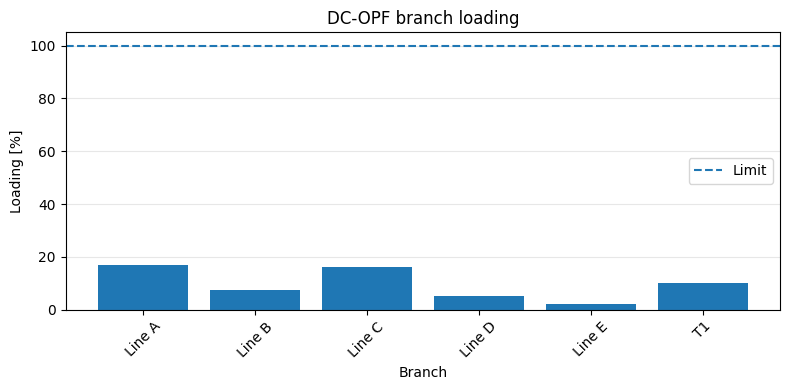

In [16]:

# Plot branch loading


fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(branch_results["name"].astype(str), branch_results["loading_percent"])
ax.axhline(100, linestyle="--", label="Limit")

ax.set_xlabel("Branch")
ax.set_ylabel("Loading [%]")
ax.set_title("DC-OPF branch loading")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()